In [1]:
import torch.nn as nn
import torch
from C_MODELS.utils.extreme_transforms import softplus

MIN_ERFC_INV = 1e-6
PI = torch.pi


In [2]:
def _extreme_transform_and_lad(z, tail_param):
    g = torch.erfc(z / SQRT_2)+0.000001 #Aditya has added the extra 0.000..1 to handle zero power negative in the next line
    x = (torch.pow(g, -tail_param) - 1) / tail_param

    lad = torch.log(g) * (-tail_param - 1)
    lad -= 0.5 * torch.square(z)
    lad += torch.log(torch.tensor(SQRT_2 / SQRT_PI))

    return x, lad

In [3]:
def _tail_affine_transform(z, pos_tail, neg_tail, shift, scale):
    sign = torch.sign(z)
    tail_param = torch.where(z > 0, pos_tail, neg_tail)
    x, lad = _extreme_transform_and_lad(torch.abs(z), tail_param)
    lad += torch.log(scale)
    return sign * x * scale + shift, lad

In [4]:
def _stable_erfcinv(x, log_x):
    # print("CORRECT")
    x = torch.clamp(x, min=MIN_ERFC_INV)  # Or any small positive value
    return -torch.special.ndtri(0.5 * x) / torch.sqrt(torch.tensor(2.0))

def dTTFInverse_dz(x, pos_tail, neg_tail,shift, scale): #aditya wrote this
    s = torch.sign(x - shift)
    
    # Compute λₛ based on sign
    lambda_s = torch.where(s > 0, pos_tail, neg_tail)
    
    # Compute y = λₛ|(x - μ)/σ| + 1
    y = lambda_s * torch.abs((x - shift) / scale) + 1
    
    # Compute y^{-1/λₛ - 1}
    y_pow = torch.pow(y, -1.0/lambda_s - 1)
    
    # Compute erfc^{-1}(y^{-1/λₛ})
    # Note: PyTorch doesn't have direct erfc inverse, so we use inverse of erf and adjust
    # erfc(z) = 1 - erf(z) => erfc^{-1}(w) = erf^{-1}(1 - w)
    w = torch.pow(y, -1.0/lambda_s)
    erfcinv_w =_stable_erfcinv(w, torch.log(w)) #torch.erfinv(1 - w)
    
    # Compute exp(erfcinv_w^2)
    exp_term = torch.exp(torch.square(erfcinv_w))
    
    # Combine all terms
    grad = (1 / scale) * (SQRT_PI/SQRT_2) * y_pow * exp_term
    
    return grad   

def _tail_affine_inverse(x, pos_tail, neg_tail, shift, scale):
    # affine
    x = (x - shift) / scale

    # tail transform
    sign = torch.sign(x)
    tail_param = torch.where(x > 0, pos_tail, neg_tail)

    z, lad = _extreme_inverse_and_lad(torch.abs(x), torch.abs(tail_param))

    lad -= torch.log(scale)
    return sign * z, lad

def _extreme_inverse_and_lad(x, tail_param):
    inner = 1 + tail_param * x
    g = torch.pow(inner, -1 / tail_param)
    log_g = -torch.log(inner) / tail_param
    erfcinv_val = _stable_erfcinv(g, log_g)

    z = SQRT_2 * erfcinv_val

    lad = (-1 - 1 / tail_param) * torch.log(inner)
    lad += torch.square(erfcinv_val)
    lad += torch.log(torch.tensor(SQRT_PI / SQRT_2))

    return z, lad

In [5]:
class TailAffineMarginalTransform_SeparateNetParam2(nn.Module):
    def __init__(
        self,device='cuda:0',dimz=20
    ):
        # self.features = features
        super(TailAffineMarginalTransform_SeparateNetParam2, self).__init__()
        self.dimz=dimz
        self.tail_param_perdim=4
        self.og_tail_shape=(self.tail_param_perdim,self.dimz)





  

    
    def pos_tail(self,x):
        return softplus(x)

    
    def neg_tail(self,x):
        return softplus(x)

    
    def scale(self,x):
        return 1e-3 + softplus(x)

    def forward(self, z,tail_param,fix_tail=False,fix_tail_param_pos=None,fix_tail_param_neg=None):
        # print("ZZZ",z.shape)
        # z=z.reshape(-1,2)
        # print("hello",tail_param.shape)
        dim=self.dimz
        dummy_tail_param=tail_param
        # print("dummy_extreme",dummy_tail_param.shape,z.shape)

        _unc_pos_tail,_unc_neg_tail,shift,_unc_scale =dummy_tail_param[:,0,:],dummy_tail_param[:,1,:],dummy_tail_param[:,2,:],dummy_tail_param[:,3,:]
        """light -> heavy"""
        if fix_tail==True:
            # print("hello11",z.shape,fix_tail_param_pos.shape,_unc_pos_tail.shape)
            fix_tail_param_pos=fix_tail_param_pos.reshape(_unc_pos_tail.shape)
            fix_tail_param_neg=fix_tail_param_neg.reshape(_unc_neg_tail.shape)

            x, lad = _tail_affine_transform(
                z, fix_tail_param_pos, fix_tail_param_neg, shift, self.scale(_unc_scale)
                )
        else:
            x, lad = _tail_affine_transform(
                z, self.pos_tail(_unc_pos_tail), self.neg_tail(_unc_neg_tail), shift, self.scale(_unc_scale)
            )
        return x
    
    def fwd_dTTFInverse_dz(self,z,tail_param):

        dim=self.dimz
        dummy_tail_param=tail_param.reshape(tail_param.shape[0],self.og_tail_shape[0],self.og_tail_shape[1])

        _unc_pos_tail,_unc_neg_tail,shift,_unc_scale =dummy_tail_param[:,0,:],dummy_tail_param[:,1,:],dummy_tail_param[:,2,:],dummy_tail_param[:,3,:]            

        return torch.diag_embed((dTTFInverse_dz(z,  self.pos_tail(_unc_pos_tail), self.neg_tail(_unc_neg_tail), shift, self.scale(_unc_scale))))
    
    def inverse(self, x,tail_param, fix_tail=False,fix_tail_param_pos=None,fix_tail_param_neg=None):
        """heavy -> light"""
        dim=self.dimz
        # x=x.reshape(-1,2)
        nan7=torch.isnan(tail_param).any()
        if nan7:
            print("tail has nan")
        dim=self.dimz
        dummy_tail_param=tail_param.reshape(tail_param.shape[0],self.og_tail_shape[0],self.og_tail_shape[1])

        _unc_pos_tail,_unc_neg_tail,shift,_unc_scale =dummy_tail_param[:,0,:],dummy_tail_param[:,1,:],dummy_tail_param[:,2,:],dummy_tail_param[:,3,:]        # print("HHHH-",_unc_pos_tail.shape)
        if fix_tail==True:
            # print("hello",fix_tail_param_pos.shape,_unc_pos_tail.shape)
            fix_tail_param_pos=fix_tail_param_pos.reshape(_unc_pos_tail.shape)
            fix_tail_param_neg=fix_tail_param_neg.reshape(_unc_neg_tail.shape) 

            z, lad = _tail_affine_inverse(
                x, fix_tail_param_pos,fix_tail_param_neg , shift, self.scale(_unc_scale)
                )
        else:
            z, lad = _tail_affine_inverse(
                x, self.pos_tail(_unc_pos_tail), self.neg_tail(_unc_neg_tail), shift, self.scale(_unc_scale)
                )
        return z


In [6]:
batch=100000

In [7]:
tail_param=torch.zeros(batch,4,2)
tail_param[:,0,:]=tail_param[:,1,:]=-2
tail_param[:,3,:]=1


SQRT_2=torch.sqrt(torch.tensor(2))
SQRT_PI=torch.pi

In [8]:
ttf=TailAffineMarginalTransform_SeparateNetParam2(dimz=2)

In [41]:
import numpy as np
import matplotlib.pyplot as plt

def plot_2d_input_function(func, dim_input=0, dim_output=0, fixed_value=0.0, x_range=(-20, 20), num_points=1000):
    """
    Plots a function that takes batch x 2 input and returns batch x 2 output,
    but only one input dimension is varied and one output dimension is plotted.

    Parameters:
        func (callable): Function that maps (batch x 2) -> (batch x 2).
        dim_input (int): Index of input dimension to vary (0 or 1).
        dim_output (int): Index of output dimension to plot (0 or 1).
        fixed_value (float): Fixed value for the non-varying input dimension.
        x_range (tuple): Range for the input dimension being varied.
        num_points (int): Number of points in the plot.
    """
    x_vals = np.linspace(x_range[0], x_range[1], num_points)
    tail_param=torch.zeros(num_points,4,2)
    tail_param[:,0,:]=tail_param[:,1,:]=1
    tail_param[:,3,:]=2

    
    # Create input array with shape (num_points, 2)
    inputs = np.zeros((num_points, 2))
    inputs[:, dim_input] = x_vals
    inputs[:, 1 - dim_input] = fixed_value  # fix the other dimension

    # Apply function
    outputs = func(torch.tensor(inputs),tail_param).diagonal(dim1=1, dim2=2)  .numpy()
    print(outputs)

    # Extract the dimension of interest from the output
    y_vals =inputs[:,dim_output]/ outputs[:, dim_output]

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(x_vals, y_vals, label=f'Output dim {dim_output} vs Input dim {dim_input}')
    plt.xlabel(f'Input dim {dim_input}')
    plt.ylabel(f'Output dim {dim_output}')
    plt.title('Function plot: dim {} → dim {}'.format(dim_input, dim_output))
    plt.grid(True)
    plt.legend()
    plt.show()


[[0.032494   1.04394579]
 [0.03256486 1.04394579]
 [0.03263601 1.04394579]
 ...
 [0.03263601 1.04394579]
 [0.03256486 1.04394579]
 [0.032494   1.04394579]]


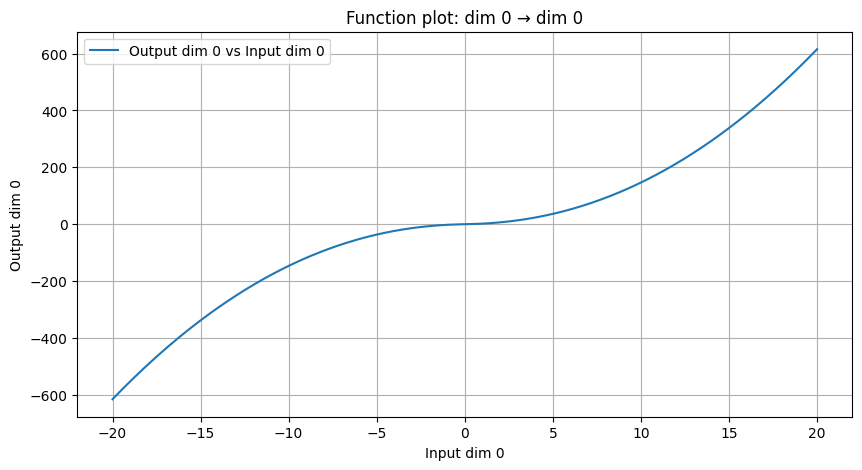

In [42]:
plot_2d_input_function(ttf.fwd_dTTFInverse_dz)

In [73]:
og=torch.randn(batch,2)*1

In [74]:
gen=ttf(og,tail_param)

C:\Users\adity\AppData\Local\Temp\ipykernel_4472\3109908207.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lad += torch.log(torch.tensor(SQRT_2 / SQRT_PI))


(-5.0, 5.0)

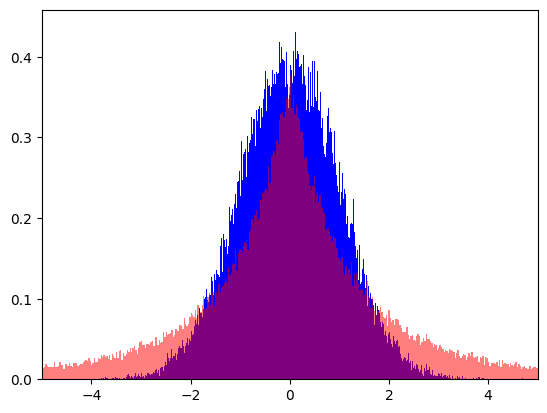

In [75]:
import matplotlib.pyplot as plt
plt.hist(og[:,0],bins=1000,density=True,color='blue')

plt.hist(gen[:,0],bins=10000,density=True,color='red',alpha=0.5)

plt.xlim(-5,5)
